In [53]:
!pip install -q monai

In [54]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from huggingface_hub import hf_hub_download
from monai.inferers import sliding_window_inference
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
hf_auth_token = user_secrets.get_secret("hf_auth_token")

HF_REPO = "AG2307/pengwin2026-anatomy-segmentation-model"
DATASET_REPO = "AG2307/pengwin-2026-anatomy-segmentation"
CHANNELS = [1, 32, 64, 128, 256, 512]
NUM_LABELS = 5
PATCH_SIZE = (96, 96, 96)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [55]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv3d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv3d(
                in_channels=out_channels,
                out_channels=out_channels,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.layers(x)
        
class Unet(nn.Module):
    def __init__(self, channels, num_labels):
        super().__init__()
        self.encoders = nn.ModuleList([
            DoubleConv(channels[i], channels[i+1])
            for i in range(len(channels)-1)
        ])
        self.decoders = nn.ModuleList([
            DoubleConv(channels[i], channels[i-1])
            for i in range(len(channels)-1, 1, -1)
        ])
        self.reduce   = nn.ModuleList([
            nn.Conv3d(
                in_channels=channels[i],
                out_channels=channels[i-1],
                kernel_size=1,
                stride=1,
                padding=0,
                bias=False,
            ) for i in range(len(channels)-1, 1, -1)
        ])
        self.pool     = nn.MaxPool3d(2)
        self.upsample = nn.Upsample(
            scale_factor=2,
            mode='trilinear',
            align_corners=True,
        )
        self.final_conv = nn.Conv3d(
            in_channels=channels[1],
            out_channels=num_labels,
            kernel_size=1,
            stride=1,
            padding=0,
            bias=True,
        )

    def forward(self, x):
        skips = []
        for enc in self.encoders[:-1]:
            x = enc(x)
            skips.append(x)
            x = self.pool(x)
        x = self.encoders[-1](x)

        skips = list(reversed(skips))
        for i, dec in enumerate(self.decoders):
            x = self.upsample(x)
            x = self.reduce[i](x)
            x = torch.cat([x, skips[i]], dim=1)
            x = dec(x)
        x = self.final_conv(x)
        return x

In [56]:
model = Unet(channels=CHANNELS, num_labels=NUM_LABELS)
ckpt_path = hf_hub_download(repo_id=HF_REPO, filename="best_model.pth", repo_type="model", token = hf_auth_token)
ckpt = torch.load(ckpt_path, map_location="cpu")
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)
model.eval()
print(f"Loaded model from epoch {ckpt['epoch']}, dice {ckpt['best_dice']:.4f}")

Loaded model from epoch 16, dice 0.9018


In [57]:
data = load_dataset(DATASET_REPO, split="validation")
data = data.with_format("torch")

idx = np.random.randint(len(data))
sample = data[idx]
image = sample["image"].unsqueeze(0).to(device)
label = sample["label"]
print(f"Showing validation case {idx}, image shape {image.shape}")

Showing validation case 17, image shape torch.Size([1, 1, 359, 228, 267])


In [58]:
with torch.no_grad():
    pred = sliding_window_inference(
        inputs=image, roi_size=PATCH_SIZE, sw_batch_size=2,
        predictor=model, overlap=0.25, mode="gaussian",
    )
pred_hard = torch.argmax(pred, dim=1).squeeze(0).cpu().numpy()

image_np = image.squeeze().cpu().numpy()
label_np = label.squeeze().cpu().numpy()

print("GT labels present:", np.unique(label_np))
print("Pred labels present:", np.unique(pred_hard))

GT labels present: [0 1 2 3]
Pred labels present: [0 1 2 3 4]


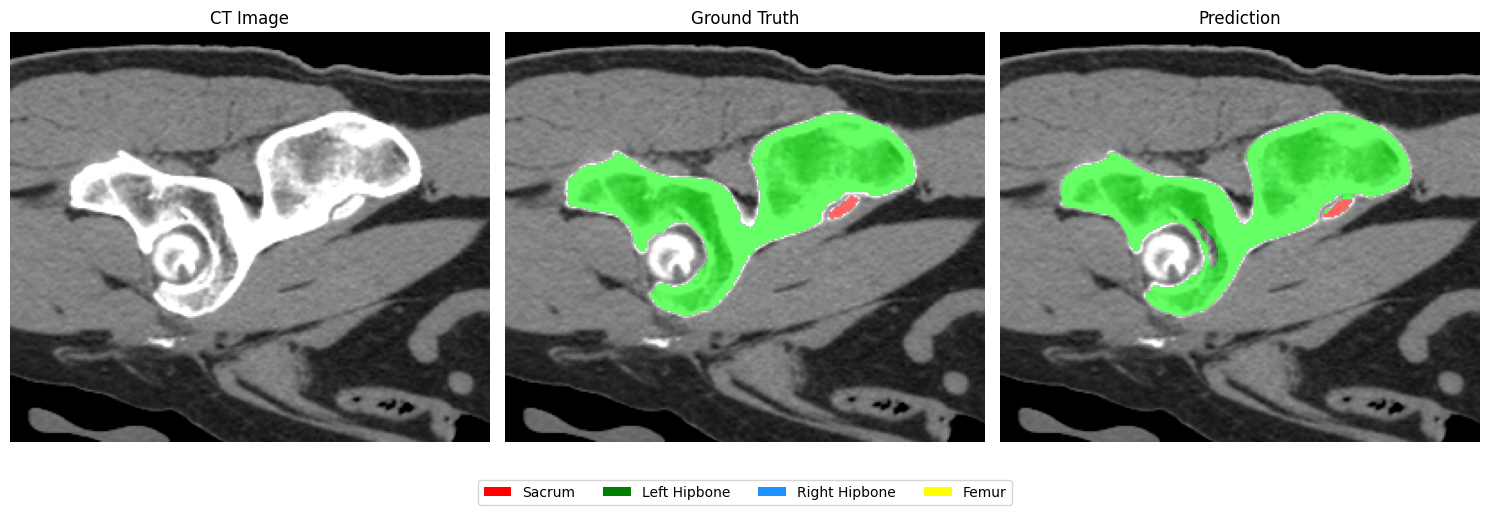

In [59]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np

# discrete colormap — one color per label
# 0=background, 1=sacrum, 2=left hip, 3=right hip, 4=femur
label_colors = [
    (0, 0, 0, 0),        # 0 background — fully transparent
    (1, 0, 0, 0.6),      # 1 sacrum — red
    (0, 1, 0, 0.6),      # 2 left hipbone — green
    (0, 0.5, 1, 0.6),    # 3 right hipbone — blue
    (1, 1, 0, 0.6),      # 4 femur — yellow
]
cmap = ListedColormap(label_colors)
norm = BoundaryNorm(boundaries=np.arange(-0.5, NUM_LABELS + 0.5), ncolors=NUM_LABELS)

# pick the most informative slice
fg_per_slice = (label_np > 0).sum(axis=(1, 2))
best_slice = np.argmax(fg_per_slice)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image_np[best_slice], cmap="gray")
axes[0].set_title("CT Image")
axes[0].axis("off")

axes[1].imshow(image_np[best_slice], cmap="gray")
axes[1].imshow(label_np[best_slice], cmap=cmap, norm=norm)
axes[1].set_title("Ground Truth")
axes[1].axis("off")

axes[2].imshow(image_np[best_slice], cmap="gray")
axes[2].imshow(pred_hard[best_slice], cmap=cmap, norm=norm)
axes[2].set_title("Prediction")
axes[2].axis("off")

# legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="red", label="Sacrum"),
    Patch(facecolor="green", label="Left Hipbone"),
    Patch(facecolor="dodgerblue", label="Right Hipbone"),
    Patch(facecolor="yellow", label="Femur"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()